In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [3]:
emin, emax = 0, 10
cmin, cmax = 0, 10

imin, imax = 0, 0.1

#interaction_type = 0

#f = fCC

'''
def get_boolean(f, interaction_type):
    event_counter = f.root.EventCounter.col("value")
    print(event_counter)
    print('started counter')
    
    #energy = f.root.PrimaryEnergy.col("value")#f.root.PrimaryEnergy.col("value")
    #inelasticity = f.root.Inelasticity.col("value")
    
    trueX = f.root.TrueX.col("value")
    trueY = f.root.TrueY.col("value")
    trueZ = f.root.TrueZ.col("value")
    
    #energy_boolean = (energy >= emin) & (energy <= emax)
    #inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
    
    vertex_boolean = (trueZ <= uz+150)&(trueZ >= uz-150)&(trueX <= ux+50)&(trueX >= ux-50)&(trueY <= uy+40)&(trueY >= uy-40)
    print('defined booleans')
    
    if interaction_type == 0:
        energy = f.root.RecoEnergy.col("value") #f.root.PrimaryEnergy.col("value")
        energy_boolean = (energy >= emin) & (energy <= emax)
        
        inelasticity = f.root.Inelasticity.col("value")
        inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
        
        event_boolean = energy_boolean & inelasticity_boolean & vertex_boolean
    if interaction_type == 1:
        energy = f.root.RecoEnergy.col("value") #f.root.SecondaryEnergy.col("value")
        energy_boolean = (energy >= emin) & (energy <= emax)
        
        event_boolean = energy_boolean & vertex_boolean

    return event_boolean

'''

def get_boolean(f, interaction_type):
    if interaction_type == 0:
        energy = f.root.PrimaryEnergy.col('value')

    if interaction_type == 1:
        energy = f.root.SecondaryEnergy.col('value')

    renergy = f.root.RecoEnergy.col('value')
    total_charge = f.root.TotalCharge.col('value')

    energy_boolean = (energy >= emin) & (energy <= emax)
    reco_energy_boolean = (renergy >= emin) & (renergy <= emax)
    total_charge_boolean = (total_charge >= cmin) & (total_charge <= cmax)

    return energy_boolean, reco_energy_boolean, total_charge_boolean

In [4]:
event_booleanCC, reco_event_booleanCC, total_charge_booleanCC = get_boolean(fCC, 0)
event_booleanNC, reco_event_booleanNC, total_charge_booleanNC  = get_boolean(fNC, 1)

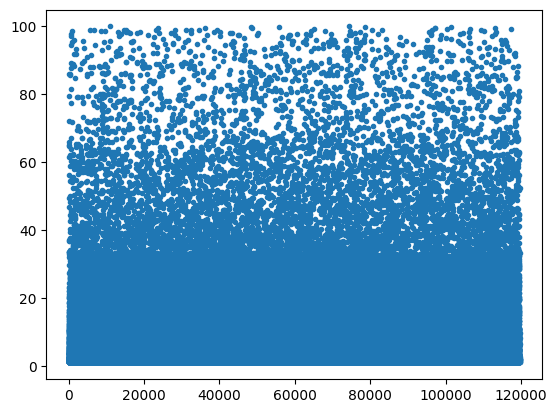

In [5]:
plt.plot(fCC.root.PrimaryEnergy.col('value'), '.')

In [8]:
def make1D_histograms(trueCC, trueNC, recoCC, recoNC, label, energy=True):

    trueCC = trueCC[~np.isnan(trueCC)]
    trueNC = trueNC[~np.isnan(trueNC)]

    recoCC = recoCC[~np.isnan(recoCC)]
    recoNC = recoNC[~np.isnan(recoNC)]

    ks_statistic_true, pvalue_true = ks_2samp(trueCC, trueNC)

    ks_statistic_reco, pvalue_reco = ks_2samp(recoCC, recoNC)

    combined_min = min(trueCC.min(), trueNC.min())
    combined_max = max(trueCC.max(), trueNC.max())

    n_bins = 100
    bin_edges = np.linspace(combined_min, combined_max, n_bins + 1)

    if energy:
        title = 'Energy {} - {} GeV'.format(emin, emax)
    else:
        title = 'Charge {} - {}'.format(emin, emax)
        
    plt.hist(trueCC, bins = bin_edges, histtype='step', log = True, density=True, label='CC', lw=1.5)
    plt.hist(trueNC, bins = bin_edges, histtype='step', log = True, density=True, label='NC', lw=1.5)
    plt.legend()
    plt.text(0.7, 0.65, r'KS statistic = ' + str(np.round(ks_statistic_true, 3)), transform=plt.gca().transAxes)
    plt.text(0.7, 0.60, r'p-value = ' + str(np.round(pvalue_true, 3)), transform=plt.gca().transAxes)
    plt.xlabel(label)
    plt.title(title+'|True')

    plt.show()

    combined_min = min(recoCC.min(), recoNC.min())
    combined_max = max(recoCC.max(), recoNC.max())

    n_bins = 100
    bin_edges = np.linspace(combined_min, combined_max, n_bins + 1)

    plt.hist(recoCC, bins = bin_edges, histtype='step', log = True, density=True, label='CC', lw=1.5)
    plt.hist(recoNC, bins = bin_edges, histtype='step', log = True, density=True, label='NC', lw=1.5)
    plt.legend()
    plt.text(0.7, 0.65, r'KS statistic = ' + str(np.round(ks_statistic_reco, 3)), transform=plt.gca().transAxes)
    plt.text(0.7, 0.60, r'p-value = ' + str(np.round(pvalue_reco, 3)), transform=plt.gca().transAxes)
    plt.xlabel(label)
    plt.title(title+'|Reco')

    plt.show()

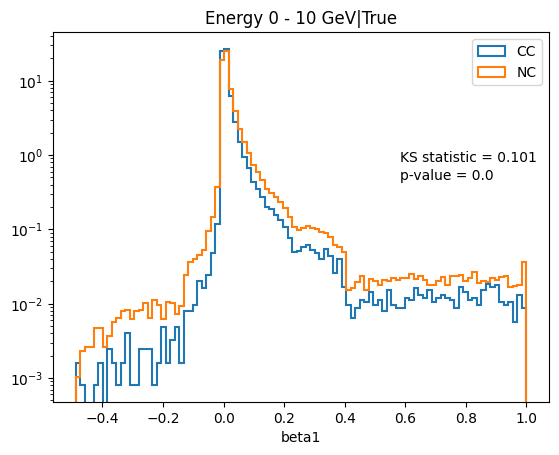

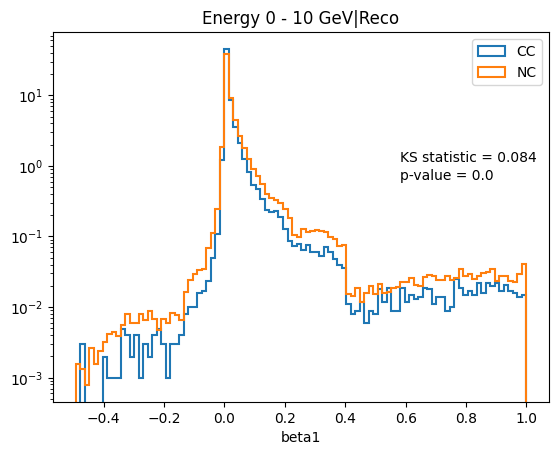

In [9]:
make1D_histograms(fCC.root.Beta1.col('value')[event_booleanCC], fNC.root.Beta1.col('value')[event_booleanNC],
                  fCC.root.Beta1Reco.col('value')[reco_event_booleanCC], fNC.root.Beta1Reco.col('value')[reco_event_booleanNC],
                  'beta1')

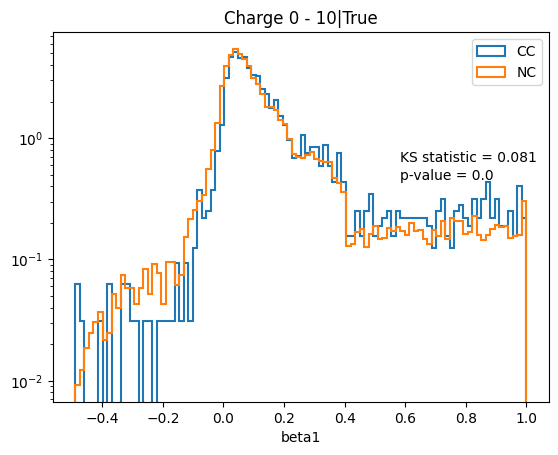

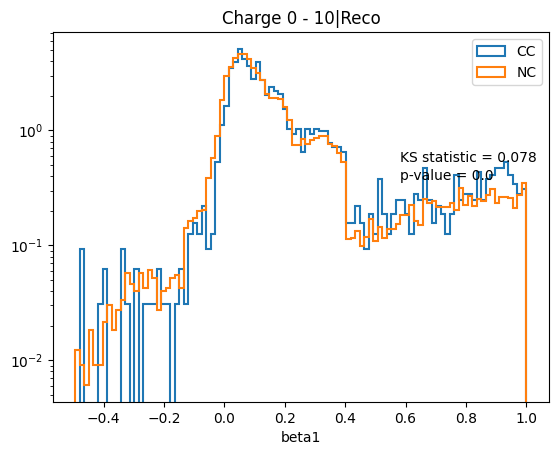

In [19]:
make1D_histograms(fCC.root.Beta1.col('value')[total_charge_booleanCC], fNC.root.Beta1.col('value')[total_charge_booleanNC],
                  fCC.root.Beta1Reco.col('value')[total_charge_booleanCC], fNC.root.Beta1Reco.col('value')[total_charge_booleanNC],
                  'beta1', energy=False)

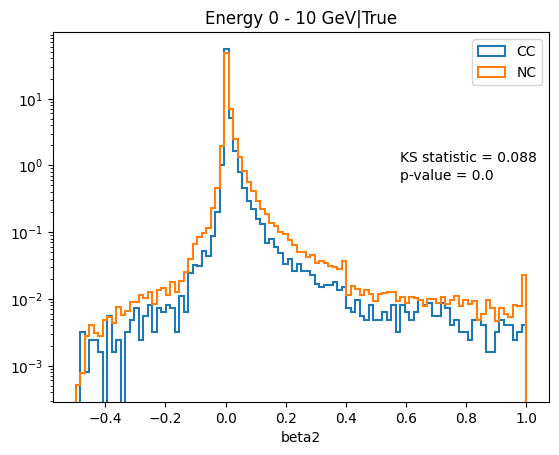

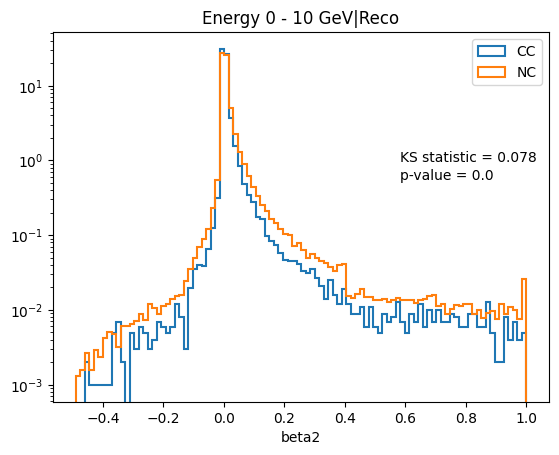

In [10]:
make1D_histograms(fCC.root.Beta2.col('value')[event_booleanCC], fNC.root.Beta2.col('value')[event_booleanNC],
                  fCC.root.Beta2Reco.col('value')[reco_event_booleanCC], fNC.root.Beta2Reco.col('value')[reco_event_booleanNC],
                  'beta2')

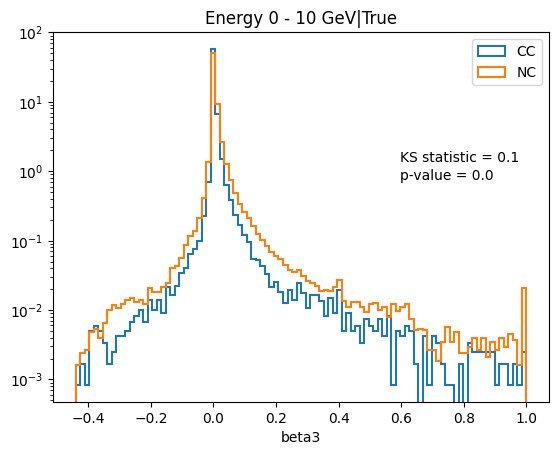

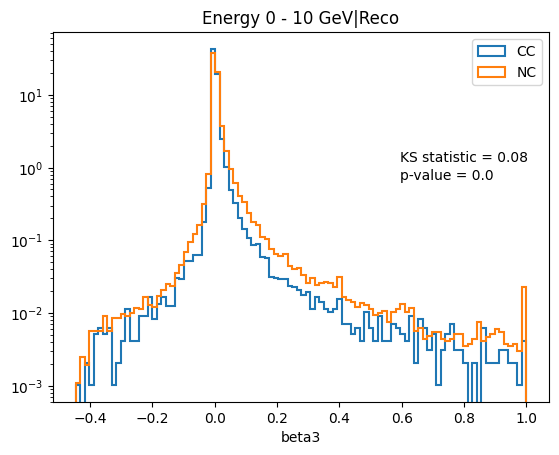

In [11]:
make1D_histograms(fCC.root.Beta3.col('value')[event_booleanCC], fNC.root.Beta3.col('value')[event_booleanNC],
                  fCC.root.Beta3Reco.col('value')[reco_event_booleanCC], fNC.root.Beta3Reco.col('value')[reco_event_booleanNC],
                  'beta3')

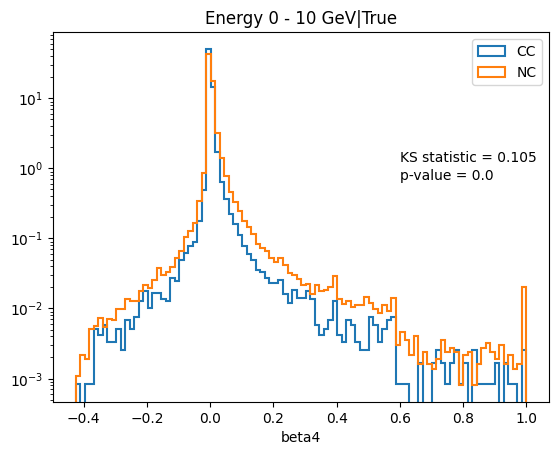

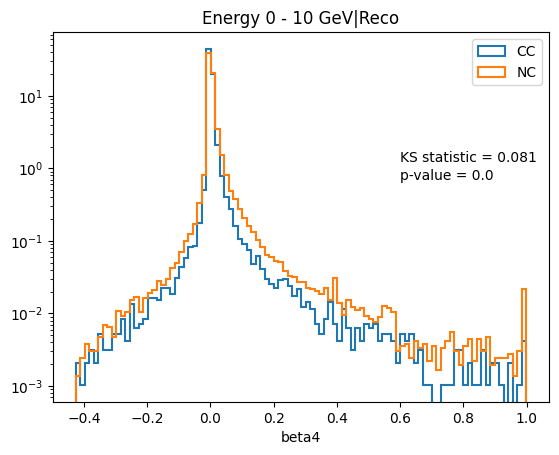

In [12]:
make1D_histograms(fCC.root.Beta4.col('value')[event_booleanCC], fNC.root.Beta4.col('value')[event_booleanNC],
                  fCC.root.Beta4Reco.col('value')[reco_event_booleanCC], fNC.root.Beta4Reco.col('value')[reco_event_booleanNC],
                  'beta4')

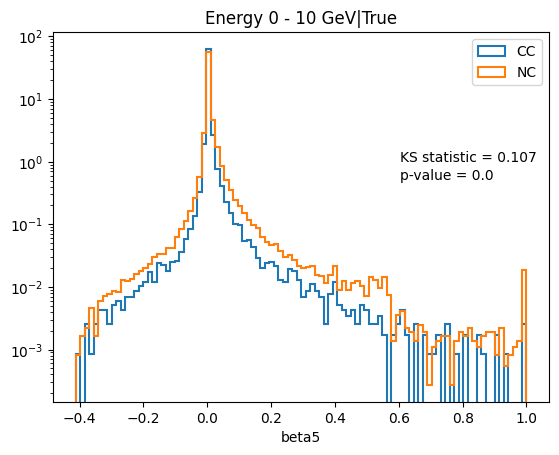

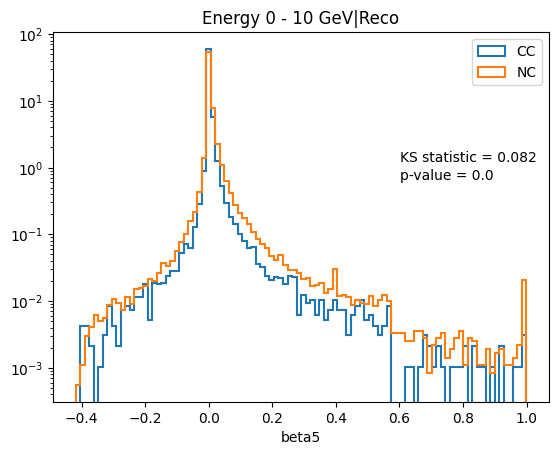

In [13]:
make1D_histograms(fCC.root.Beta5.col('value')[event_booleanCC], fNC.root.Beta5.col('value')[event_booleanNC],
                  fCC.root.Beta5Reco.col('value')[reco_event_booleanCC], fNC.root.Beta5Reco.col('value')[reco_event_booleanNC],
                  'beta5')

In [20]:
true_cogDistCC = np.sqrt((fCC.root.TrueX.col('value')[total_charge_booleanCC]-fCC.root.CogX.col('value')[total_charge_booleanCC])**2+
                    (fCC.root.TrueY.col('value')[total_charge_booleanCC]-fCC.root.CogY.col('value')[total_charge_booleanCC])**2+ 
                    (fCC.root.TrueZ.col('value')[total_charge_booleanCC]-fCC.root.CogZ.col('value')[total_charge_booleanCC])**2)

true_cogDistNC = np.sqrt((fNC.root.TrueX.col('value')[total_charge_booleanNC]-fNC.root.CogX.col('value')[total_charge_booleanNC])**2+
                    (fNC.root.TrueY.col('value')[total_charge_booleanNC]-fNC.root.CogY.col('value')[total_charge_booleanNC])**2+
                    (fNC.root.TrueZ.col('value')[total_charge_booleanNC]-fNC.root.CogZ.col('value')[total_charge_booleanNC])**2)

In [21]:
reco_cogDistCC = np.sqrt((fCC.root.RecoX.col('value')[total_charge_booleanCC]-fCC.root.CogX.col('value')[total_charge_booleanCC])**2+
                    (fCC.root.RecoY.col('value')[total_charge_booleanCC]-fCC.root.CogY.col('value')[total_charge_booleanCC])**2+ 
                    (fCC.root.RecoZ.col('value')[total_charge_booleanCC]-fCC.root.CogZ.col('value')[total_charge_booleanCC])**2)

reco_cogDistNC = np.sqrt((fNC.root.RecoX.col('value')[total_charge_booleanNC]-fNC.root.CogX.col('value')[total_charge_booleanNC])**2+
                    (fNC.root.RecoY.col('value')[total_charge_booleanNC]-fNC.root.CogY.col('value')[total_charge_booleanNC])**2+
                    (fNC.root.RecoZ.col('value')[total_charge_booleanNC]-fNC.root.CogZ.col('value')[total_charge_booleanNC])**2)

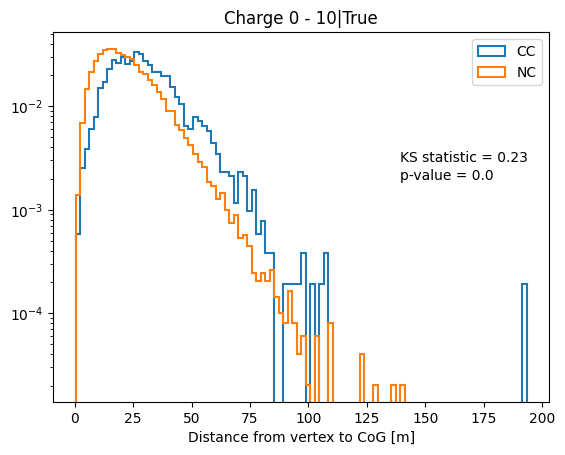

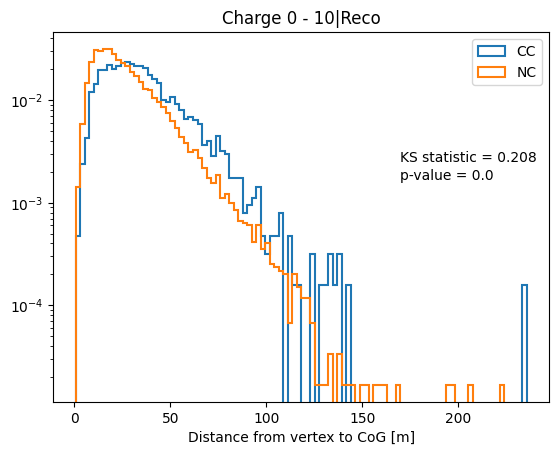

In [23]:
make1D_histograms(true_cogDistCC, true_cogDistNC ,
                  reco_cogDistCC, reco_cogDistNC,
                  'Distance from vertex to CoG [m]', energy=False)

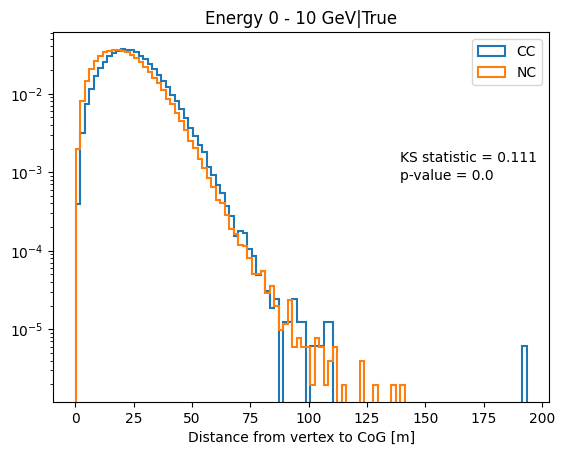

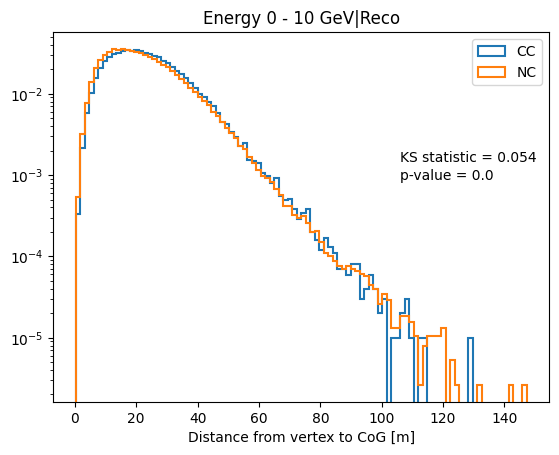

In [24]:
true_cogDistCC = np.sqrt((fCC.root.TrueX.col('value')[event_booleanCC]-fCC.root.CogX.col('value')[event_booleanCC])**2+
                    (fCC.root.TrueY.col('value')[event_booleanCC]-fCC.root.CogY.col('value')[event_booleanCC])**2+ 
                    (fCC.root.TrueZ.col('value')[event_booleanCC]-fCC.root.CogZ.col('value')[event_booleanCC])**2)

true_cogDistNC = np.sqrt((fNC.root.TrueX.col('value')[event_booleanNC]-fNC.root.CogX.col('value')[event_booleanNC])**2+
                    (fNC.root.TrueY.col('value')[event_booleanNC]-fNC.root.CogY.col('value')[event_booleanNC])**2+
                    (fNC.root.TrueZ.col('value')[event_booleanNC]-fNC.root.CogZ.col('value')[event_booleanNC])**2)

reco_cogDistCC = np.sqrt((fCC.root.RecoX.col('value')[reco_event_booleanCC]-fCC.root.CogX.col('value')[reco_event_booleanCC])**2+
                    (fCC.root.RecoY.col('value')[reco_event_booleanCC]-fCC.root.CogY.col('value')[reco_event_booleanCC])**2+ 
                    (fCC.root.RecoZ.col('value')[reco_event_booleanCC]-fCC.root.CogZ.col('value')[reco_event_booleanCC])**2)

reco_cogDistNC = np.sqrt((fNC.root.RecoX.col('value')[reco_event_booleanNC]-fNC.root.CogX.col('value')[reco_event_booleanNC])**2+
                    (fNC.root.RecoY.col('value')[reco_event_booleanNC]-fNC.root.CogY.col('value')[reco_event_booleanNC])**2+
                    (fNC.root.RecoZ.col('value')[reco_event_booleanNC]-fNC.root.CogZ.col('value')[reco_event_booleanNC])**2)

make1D_histograms(true_cogDistCC, true_cogDistNC ,
                  reco_cogDistCC, reco_cogDistNC,
                  'Distance from vertex to CoG [m]')

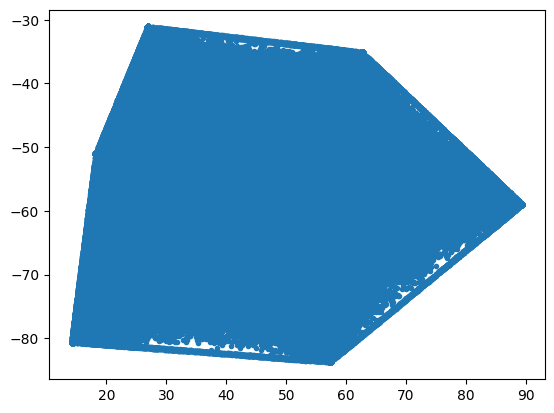

In [17]:
plt.plot(fNC.root.CogX.col('value')[event_booleanNC], fNC.root.CogY.col('value')[event_booleanNC], '.')

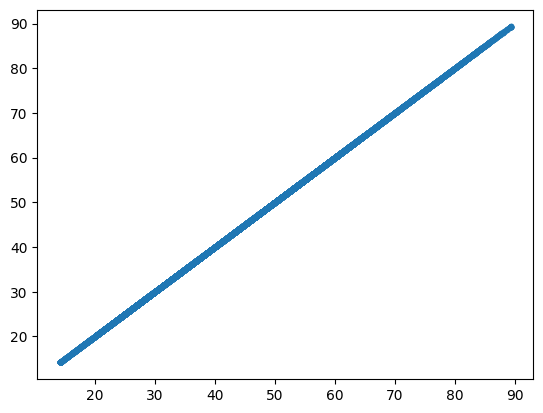

In [87]:
plt.plot(fNC.root.CogX.col('value')[event_booleanNC], fNC.root.CogZ.col('value')[event_booleanNC], '.')

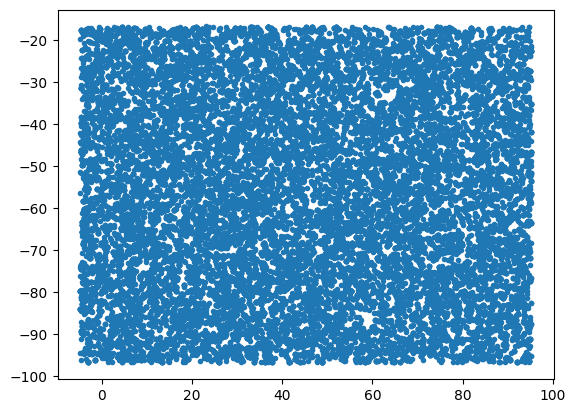

In [81]:
plt.plot(fNC.root.TrueX.col('value')[event_booleanNC], fNC.root.TrueY.col('value')[event_booleanNC], '.')

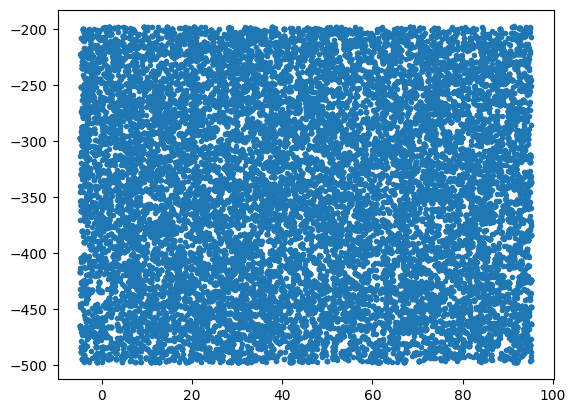

In [83]:
plt.plot(fNC.root.TrueX.col('value')[event_booleanNC], fNC.root.TrueZ.col('value')[event_booleanNC], '.')

In [2]:
import h5py

with h5py.File('/data/user/akatil/electron_neutrino/for_real/dataset_complete/enriched_h5/upgrade_genie_level4_queso_120028_00000.h5', 'r') as f:
    keys = list(f.keys())
    print(keys)

    # Access a specific dataset by key name
    data = f[keys[0]][:]
    print(data)

['Beta1', '__I3Index__', 'graphnet_dynedge_energy_reconstruction_energy_pred', 'penergy', 'senergy']
[(120028,   30, 0, 0, 1,  6.74728135e-03)
 (120028,   74, 0, 0, 1,  2.34724044e-03)
 (120028,   76, 0, 0, 1,  2.83189483e-04)
 (120028,  155, 0, 0, 1,  2.56025230e-05)
 (120028,  166, 0, 0, 1,  9.79550124e-04)
 (120028,  194, 0, 0, 1,  4.05396102e-03)
 (120028,  229, 0, 0, 1,  1.27870749e-02)
 (120028,  238, 0, 0, 1,  7.90963963e-03)
 (120028,  327, 0, 0, 1,  1.00552372e-02)
 (120028,  386, 0, 0, 1,  3.02163146e-04)
 (120028,  428, 0, 0, 1,  7.79949628e-05)
 (120028,  429, 0, 0, 1,  2.47543735e-03)
 (120028,  443, 0, 0, 1,  3.65416769e-03)
 (120028,  655, 0, 0, 1,  3.33895158e-02)
 (120028,  913, 0, 0, 1,  3.72411062e-06)
 (120028,  968, 0, 0, 1,  7.79467525e-03)
 (120028,  969, 0, 0, 1,  1.65998017e-02)
 (120028,  986, 0, 0, 1,  1.22955155e-02)
 (120028, 1008, 0, 0, 1,  1.30612697e-03)
 (120028, 1115, 0, 0, 1,  7.72089916e-03)
 (120028, 1267, 0, 0, 1,             nan)
 (120028, 1283, 0

In [3]:
import pandas as pd

# Load the HDF5 file
df = pd.read_hdf('/data/user/akatil/electron_neutrino/for_real/dataset_complete/enriched_h5/upgrade_genie_level4_queso_120028_00000.h5')

# Print the DataFrame
print(df.head())

ValueError: Dataset(s) incompatible with Pandas data types, not table, or no datasets found in HDF5 file.

In [1]:
import tables

# Open the HDF5 file
file = tables.open_file('/data/user/akatil/electron_neutrino/for_real/dataset_complete/enriched_h5/upgrade_genie_level4_queso_120028_00000.h5', mode='r')


In [2]:
file.root.Beta1.col('value')

array([ 6.74728135e-03,  2.34724044e-03,  2.83189483e-04,  2.56025230e-05,
        9.79550124e-04,  4.05396102e-03,  1.27870749e-02,  7.90963963e-03,
        1.00552372e-02,  3.02163146e-04,  7.79949628e-05,  2.47543735e-03,
        3.65416769e-03,  3.33895158e-02,  3.72411062e-06,  7.79467525e-03,
        1.65998017e-02,  1.22955155e-02,  1.30612697e-03,  7.72089916e-03,
                   nan,  2.35835856e-04,  6.68241925e-05,  7.58042520e-03,
        2.84257501e-03,  3.61540307e-06,  6.91559487e-05,  1.51808330e-02,
        3.33063357e-03,  1.29649710e-04,  1.00295736e-02,  1.11479608e-04,
        1.24031207e-02,  2.09750623e-04,  1.05592903e-03,  1.43941666e-03,
        1.21731988e-03,  4.21418192e-03,  7.84011974e-04,  5.21009689e-04,
        5.65966040e-03,  3.52993099e-02,  2.03418195e-03,  9.52992366e-04,
        2.61983276e-04,  1.09369823e-04,  2.12581742e-04,  9.49845940e-05,
        2.93310278e-03,  4.87355992e-03,  1.13372467e-04,  9.56926382e-05,
        5.40341640e-02,  

In [4]:
file.root.daughter_type.col('value')

array([12., 11., 11., 11., 11., 12., 11., 12., 11., 11., 11., 11., 12.,
       12., 11., 11., 11., 12., 11., 12., 11., 11., 11., 11., 12., 11.,
       11., 11., 11., 11., 11., 11., 11., 12., 11., 11., 11., 11., 11.,
       11., 11., 11., 11., 11., 12., 12., 12., 11., 12., 11., 12., 11.,
       12., 11., 11., 11., 11.])